# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity

# Load the Dataset

In [2]:
url = "https://raw.githubusercontent.com/Bumb1eBee20/ExcelR---Data-Science-Assignments-Submissions/dc62bfdcfc3e760b35fdcc1441be587da9234f4b/16.%20Recommendation%20Systems/data/anime.csv"
df = pd.read_csv(url)

# Preview the Dataset

In [3]:
df

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
...,...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175


# Inital Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


## Dataset Dimensions

In [5]:
print("Shape : ",df.shape)
print("Size : ",df.size)

Shape :  (12294, 7)
Size :  86058


## Checking DataTypes

In [6]:
df.dtypes

,0
anime_id,int64
name,object
genre,object
type,object
episodes,object
rating,float64
members,int64


# Data Cleaning

## Cleaning Whitespaces, Checking unqiue and value counts for Categorical Variables

In [7]:
categorical_cols = df.select_dtypes(include =  "object").columns
categorical_cols

Index(['name', 'genre', 'type', 'episodes'], dtype='object')

In [8]:
for col in categorical_cols:
  df[col] = df[col].str.strip()
  print(col)
  print("Unique Categories : ", df[col].nunique())
  print("="*50)
  print(df[col].value_counts(ascending = False))
  print("="*50)

name
Unique Categories :  12292
name
Saru Kani Gassen                                     2
Shi Wan Ge Leng Xiaohua                              2
Bary-san x Gospe Rats: Tonde Bary Bary Monogatari    1
Ba La La Xiao Mo Xian Zhi: Qiji Wubu                 1
Backkom Meogeujan Yeohaeng                           1
                                                    ..
3-gatsu no Lion meets Bump of Chicken                1
Bannou Bunka Neko-Musume                             1
Choujikuu Seiki Orguss                               1
Chuuzumou                                            1
Star Driver the Movie                                1
Name: count, Length: 12292, dtype: int64
genre
Unique Categories :  3264
genre
Hentai                                                  823
Comedy                                                  523
Music                                                   301
Kids                                                    199
Comedy, Slice of Life                  

## Changing `episodes` columns type from `object` to `nullable integer`

In [9]:
df["episodes"] = pd.to_numeric(df["episodes"],errors = "coerce")
df["episodes"] = df["episodes"].astype("Int64")

## Checking Duplicate Records and Missing Values

In [10]:
print("No.of Duplicate Records : ",df.duplicated().sum())
print("No.of Missing Values : ")
print(df.isnull().sum())

No.of Duplicate Records :  0
No.of Missing Values : 
anime_id      0
name          0
genre        62
type         25
episodes    340
rating      230
members       0
dtype: int64


## Handling Missing Values

### Handling Missing Values for Categorical Columns

In [11]:
df["genre"] = df["genre"].fillna("Unknown")
df["type"] = df["type"].fillna("Unknown")

### Handling Missing Values for Numerical Columns

In [12]:
df["episodes"] = df["episodes"].fillna(df["episodes"].median())
df["rating"] = df["rating"].fillna(df["rating"].mean())

### Missing Values after Handling

In [13]:
print("No.of Missing Values : ")
print(df.isnull().sum())

No.of Missing Values : 
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


## Observation :

The dataset contains 0 missing values after handling, and the `episodes` column is converted from `object` to a nullable integer dtype.

# Descriptive Statistics

In [14]:
df.describe()

,anime_id,episodes,rating,members
count,12294.000000,12294.0,12294.000000,1.229400e+04
mean,14058.221653,12.095412,6.473902,1.807134e+04
std,11455.294701,46.244062,1.017096,5.482068e+04
min,1.000000,1.0,1.670000,5.000000e+00
25%,3484.250000,1.0,5.900000,2.250000e+02
50%,10260.500000,2.0,6.550000,1.550000e+03
75%,24794.500000,12.0,7.170000,9.437000e+03
max,34527.000000,1818.0,10.000000,1.013917e+06


In [15]:
print("Mode : ")
print(df.mode().iloc[0])

Mode : 
anime_id                   1
name        Saru Kani Gassen
genre                 Hentai
type                      TV
episodes                   1
rating              6.473902
members                 60.0
Name: 0, dtype: object


## Observation :

- The dataset contains 12,294 anime records.
- episodes has a highly right-skewed distribution, with a mean of 12.10 and a maximum of 1,818 episodes.
- rating ranges from 1.67 to 10, with an average rating of approximately 6.47.
- members is also highly right-skewed, with a mean of about 18,071 and a maximum exceeding 1 million, indicating a few extremely popular anime.
- The mode shows that Saru Kani Gassen is the first record, with genre Hentai, type TV, and 1 episode.
- Overall, the numerical variables show substantial variation and outliers, particularly in episodes and members.

# Exploratory Data Analysis

In [16]:
categorical_cols = ["type"]
numerical_cols = df.select_dtypes(include = np.number).columns
print("categorical Columns : ",categorical_cols)
print("Numerical Columns : ",numerical_cols)

categorical Columns :  ['type']
Numerical Columns :  Index(['anime_id', 'episodes', 'rating', 'members'], dtype='object')


## Boxplot Analysis

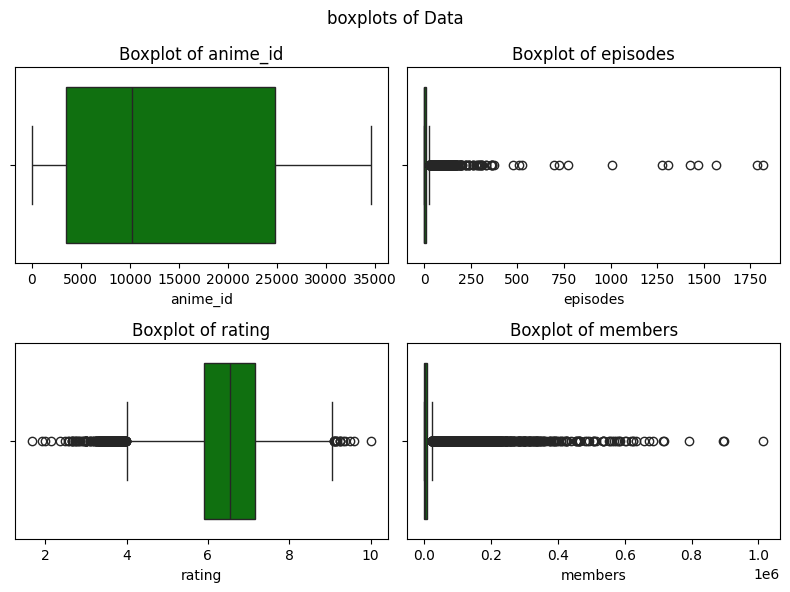

In [17]:
fig,ax = plt.subplots(2,2,figsize=(8,6))

for axis,col in zip(ax.flat,numerical_cols):
  sns.boxplot(data = df,x=col,ax=axis,color="green")
  axis.set_title(f"Boxplot of {col}")
  axis.set_xlabel(col)

for axis in ax.flat[len(numerical_cols):]:
  axis.remove()

plt.suptitle("boxplots of Data")
plt.tight_layout()
plt.show()

### Observation :

**Anime ID**

Observation: The anime_id values are widely distributed across the dataset with no significant outliers, as expected for an identifier column.

**Episodes**

Observation: The episodes variable contains many extreme outliers, indicating that most anime have relatively few episodes while a small number have very large episode counts.

**Rating**

Observation: The ratings are mainly concentrated between approximately 6 and 7.5. Several outliers are present at both the lower and higher ends of the rating range.

**Members**

Observation: The members variable contains a large number of extreme outliers, showing that most anime have relatively few members while a small number have very high popularity.

## Histogram Analysis

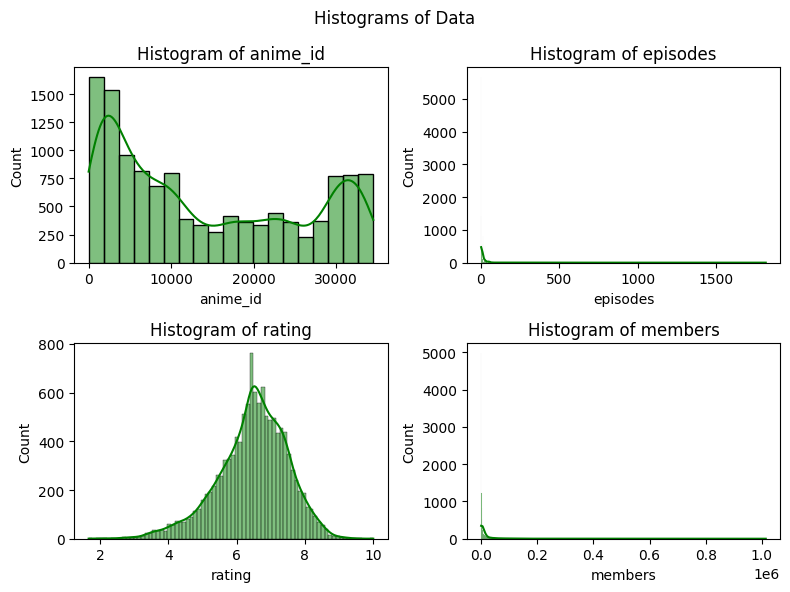

In [18]:
fig,ax = plt.subplots(2,2,figsize=(8,6))
for axis,col in zip(ax.flat,numerical_cols):
  sns.histplot(data = df,x=col,ax=axis,color="green",kde=True)
  axis.set_title(f"Histogram of {col}")
  axis.set_xlabel(col)

for axis in ax.flat[len(numerical_cols):]:
  axis.remove()

plt.suptitle("Histograms of Data")
plt.tight_layout()
plt.show()

### Observation :

**Anime ID**

Observation: The anime_id distribution is uneven across the dataset, with higher concentrations in certain ranges. Since anime_id is an identifier, its distribution does not have meaningful statistical interpretation.

**Episodes**

Observation: The episodes distribution is highly right-skewed, with most anime having a small number of episodes and very few anime having exceptionally large episode counts.

**Rating**

Observation: The rating distribution is approximately bell-shaped, with most ratings concentrated around 6–7.5 and relatively few observations at the extreme ends.

**Members**

Observation: The members distribution is highly right-skewed, with most anime having relatively low membership counts and a small number having extremely high popularity.

## Countplot Analysis

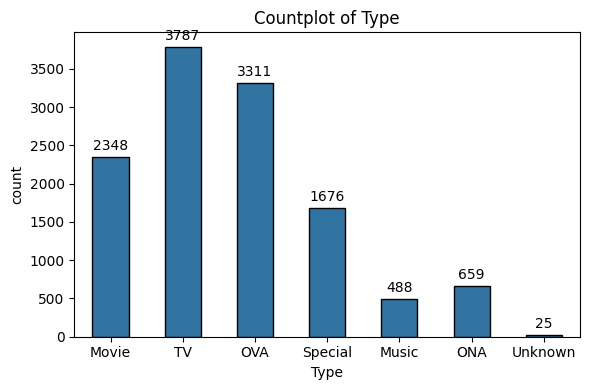

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="type", ax=ax, edgecolor="black", width=0.5)
ax.set_title("Countplot of Type")
ax.set_xlabel("Type")

for container in ax.containers:
  ax.bar_label(container,padding=3)
plt.tight_layout()
plt.show()

### Observation :

`TV` is the most common anime type with 3,787 entries, followed by `OVA` with 3,311 and `Movie` with 2,348. `Special`, `ONA`, and `Music` have comparatively fewer entries, while `Unknown` is the least common type with only 25 entries.

## Correlation Matrix

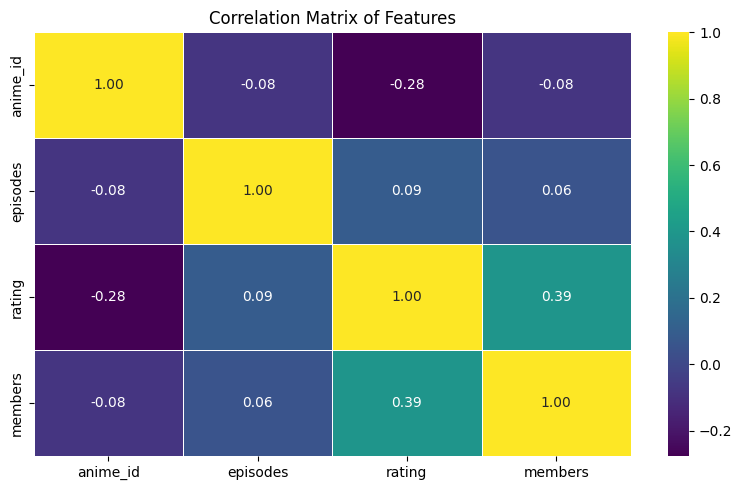

In [20]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="viridis"
)

plt.title("Correlation Matrix of Features")

plt.tight_layout()
plt.show()

### Observation :

Most numerical features show weak correlations with each other. The strongest relationship is between `rating` and `members` with a moderate positive correlation of 0.39, suggesting that higher-rated anime tend to have more members. `episodes` has very weak correlations with both `rating` (0.09) and `members` (0.06). `anime_id` also shows weak correlations and is not meaningful for predictive analysis because it is an identifier.

In [21]:
df["genre"] = df["genre"].replace("Unknown","")

# Applying TF-IDF to `Genre` variable

In [22]:
df["genre"].head(10)

,genre
0,"Drama, Romance, School, Supernatural"
1,"Action, Adventure, Drama, Fantasy, Magic, Mili..."
2,"Action, Comedy, Historical, Parody, Samurai, S..."
3,"Sci-Fi, Thriller"
4,"Action, Comedy, Historical, Parody, Samurai, S..."
5,"Comedy, Drama, School, Shounen, Sports"
6,"Action, Adventure, Shounen, Super Power"
7,"Drama, Military, Sci-Fi, Space"
8,"Action, Comedy, Historical, Parody, Samurai, S..."
9,"Action, Comedy, Historical, Parody, Samurai, S..."


In [23]:
tfidf = TfidfVectorizer(
    tokenizer=lambda x: [g for g in x.split(", ") if g]
)

genre_matrix = tfidf.fit_transform(df["genre"])

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [24]:
print("Shape:", genre_matrix.shape)
print("Genres:", tfidf.get_feature_names_out())

Shape: (12294, 43)
Genres: ['action' 'adventure' 'cars' 'comedy' 'dementia' 'demons' 'drama' 'ecchi'
 'fantasy' 'game' 'harem' 'hentai' 'historical' 'horror' 'josei' 'kids'
 'magic' 'martial arts' 'mecha' 'military' 'music' 'mystery' 'parody'
 'police' 'psychological' 'romance' 'samurai' 'school' 'sci-fi' 'seinen'
 'shoujo' 'shoujo ai' 'shounen' 'shounen ai' 'slice of life' 'space'
 'sports' 'super power' 'supernatural' 'thriller' 'vampire' 'yaoi' 'yuri']


In [25]:
genre_df = pd.DataFrame(
    genre_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

genre_df.head()

,action,adventure,cars,comedy,dementia,demons,drama,ecchi,fantasy,game,...,shounen ai,slice of life,space,sports,super power,supernatural,thriller,vampire,yaoi,yuri
0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.440247,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.544416,0.000000,0.0,0.0,0.0
1,0.294186,0.317108,0.0,0.000000,0.0,0.0,0.335306,0.0,0.319107,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
2,0.260989,0.000000,0.0,0.209063,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
3,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.905637,0.0,0.0,0.0
4,0.260989,0.000000,0.0,0.209063,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0


# Encoding

In [26]:
encoder = OneHotEncoder(sparse_output=False,handle_unknown = "ignore")

type_encoded = encoder.fit_transform(df[["type"]])

In [27]:
type_encoded.shape

(12294, 7)

In [28]:
encoder.get_feature_names_out(["type"])

array(['type_Movie', 'type_Music', 'type_ONA', 'type_OVA', 'type_Special',
       'type_TV', 'type_Unknown'], dtype=object)

In [29]:
type_df = pd.DataFrame(type_encoded,columns = encoder.get_feature_names_out(["type"]),index=df.index)
type_df.head()

,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,type_Unknown
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Scaling Numerical Features

In [30]:
df["members"] = np.log1p(df["members"])
df["episodes"] = np.log1p(df["episodes"])

numerical_features = ["episodes", "rating", "members"]

X_num = df[numerical_features]

scaler = StandardScaler()

num_scaled = scaler.fit_transform(X_num)

num_df = pd.DataFrame(
    num_scaled,
    columns=numerical_features,
    index=df.index
)

num_df.head()

,episodes,rating,members
0,-0.800242,2.847535,2.060713
1,2.171069,2.739380,2.653134
2,1.980612,2.729547,1.818193
3,1.355520,2.650889,2.582456
4,1.980612,2.641057,1.939049


In [31]:
num_df.describe()

,episodes,rating,members
count,1.229400e+04,1.229400e+04,1.229400e+04
mean,-5.548406e-17,-2.959150e-16,3.698937e-17
std,1.000041e+00,1.000041e+00,1.000041e+00
min,-8.002418e-01,-4.723348e+00,-2.427033e+00
25%,-8.002418e-01,-5.642782e-01,-8.637901e-01
50%,-4.541688e-01,7.482226e-02,-3.403561e-02
75%,7.973805e-01,6.844258e-01,7.439052e-01
max,5.014707e+00,3.466971e+00,2.758641e+00


# Combining All Features

In [32]:
final_features = pd.concat(
    [genre_df, type_df, num_df],
    axis=1
)

In [33]:
final_features.shape

(12294, 53)

In [34]:
final_features.head()

,action,adventure,cars,comedy,dementia,demons,drama,ecchi,fantasy,game,...,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,type_Unknown,episodes,rating,members
0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.440247,0.0,0.000000,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.800242,2.847535,2.060713
1,0.294186,0.317108,0.0,0.000000,0.0,0.0,0.335306,0.0,0.319107,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.171069,2.739380,2.653134
2,0.260989,0.000000,0.0,0.209063,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.980612,2.729547,1.818193
3,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.355520,2.650889,2.582456
4,0.260989,0.000000,0.0,0.209063,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.980612,2.641057,1.939049


# Cosine Similarity

In [35]:
similarity_matrix = cosine_similarity(final_features)
print("Shape : ",similarity_matrix.shape)

Shape :  (12294, 12294)


In [36]:
anime_indices = pd.Series(
    df.index,
    index=df["name"]
).drop_duplicates()

In [37]:
anime_indices["Naruto"]

np.int64(841)

# Content-Based Recommendation

In [38]:
def recommend_anime(anime_name, n=10):

    # Check whether anime exists
    if anime_name not in anime_indices:
        return f"Anime '{anime_name}' not found."

    # Get index of target anime
    idx = anime_indices[anime_name]

    # Get similarity scores
    similarity_scores = list(enumerate(similarity_matrix[idx]))

    # Sort by similarity, highest first
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the anime itself
    similarity_scores = similarity_scores[1:n+1]

    # Get anime indices
    anime_ids = [i[0] for i in similarity_scores]

    # Get similarity scores
    scores = [i[1] for i in similarity_scores]

    # Create result
    recommendations = df.iloc[anime_ids][["name", "genre", "type", "rating"]].copy()

    recommendations["similarity"] = scores

    return recommendations

In [39]:
recommend_anime("Naruto")

,name,genre,type,rating,similarity
206,Dragon Ball Z,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,8.32,0.987699
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",TV,8.16,0.985732
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,7.95,0.983485
588,Dragon Ball Kai,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,7.95,0.983119
175,Katekyo Hitman Reborn!,"Action, Comedy, Shounen, Super Power",TV,8.37,0.977677
1796,Rekka no Honoo,"Action, Adventure, Martial Arts, Shounen, Supe...",TV,7.44,0.966512
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",TV,8.22,0.963616
733,Ranma ½,"Comedy, Fantasy, Martial Arts, Slice of Life",TV,7.87,0.963023
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",TV,8.20,0.960182
515,Dragon Ball Kai (2014),"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,8.01,0.959380


In [40]:
genre_similarity = cosine_similarity(genre_matrix)

In [41]:
idx = anime_indices["Naruto"]

genre_scores = list(enumerate(genre_similarity[idx]))

genre_scores = sorted(
    genre_scores,
    key=lambda x: x[1],
    reverse=True
)

genre_scores = genre_scores[1:11]

df.iloc[[i[0] for i in genre_scores]][
    ["name", "genre", "type", "rating"]
]

,name,genre,type,rating
615,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.94
841,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.81
1103,Boruto: Naruto the Movie - Naruto ga Hokage ni...,"Action, Comedy, Martial Arts, Shounen, Super P...",Special,7.68
1343,Naruto x UT,"Action, Comedy, Martial Arts, Shounen, Super P...",OVA,7.58
1472,Naruto: Shippuuden Movie 4 - The Lost Tower,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.53
1573,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.50
2458,Naruto Shippuuden: Sunny Side Battle,"Action, Comedy, Martial Arts, Shounen, Super P...",Special,7.26
2997,Naruto Soyokazeden Movie: Naruto to Mashin to ...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.11
7628,Kyutai Panic Adventure!,"Action, Martial Arts, Shounen, Super Power",Special,5.21
784,Naruto: Shippuuden Movie 6 - Road to Ninja,"Action, Adventure, Martial Arts, Shounen, Supe...",Movie,7.84


# Threshold Experiment

In [42]:
def recommend_anime(anime_name, threshold=0.7):

    if anime_name not in anime_indices:
        return f"Anime '{anime_name}' not found."

    idx = anime_indices[anime_name]

    similarity_scores = list(
        enumerate(similarity_matrix[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the anime itself
    similarity_scores = similarity_scores[1:]

    # Apply threshold
    similarity_scores = [
        (i, score)
        for i, score in similarity_scores
        if score >= threshold
    ]

    anime_ids = [i[0] for i in similarity_scores]
    scores = [i[1] for i in similarity_scores]

    recommendations = df.iloc[anime_ids][
        ["name", "genre", "type", "rating"]
    ].copy()

    recommendations["similarity"] = scores

    return recommendations

In [43]:
recommend_anime("Naruto", threshold=0.9)

,name,genre,type,rating,similarity
206,Dragon Ball Z,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,8.32,0.987699
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",TV,8.16,0.985732
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,7.95,0.983485
588,Dragon Ball Kai,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,7.95,0.983119
175,Katekyo Hitman Reborn!,"Action, Comedy, Shounen, Super Power",TV,8.37,0.977677
...,...,...,...,...,...
696,Mobile Suit Gundam,"Action, Mecha, Military, Sci-Fi, Space",TV,7.89,0.901290
4229,Bakuten Shoot Beyblade 2002,"Action, Adventure, Comedy, Sci-Fi, Shounen, Sp...",TV,6.77,0.901139
3243,Digimon Xros Wars,"Action, Adventure, Comedy, Fantasy, Shounen",TV,7.04,0.901106
2995,Mermaid Melody Pichi Pichi Pitch,"Adventure, Comedy, Magic, Romance, Shoujo",TV,7.11,0.900706


In [44]:
recommend_anime("Naruto", threshold=0.95)

,name,genre,type,rating,similarity
206,Dragon Ball Z,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,8.32,0.987699
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",TV,8.16,0.985732
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,7.95,0.983485
588,Dragon Ball Kai,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,7.95,0.983119
175,Katekyo Hitman Reborn!,"Action, Comedy, Shounen, Super Power",TV,8.37,0.977677
1796,Rekka no Honoo,"Action, Adventure, Martial Arts, Shounen, Supe...",TV,7.44,0.966512
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",TV,8.22,0.963616
733,Ranma ½,"Comedy, Fantasy, Martial Arts, Slice of Life",TV,7.87,0.963023
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",TV,8.20,0.960182
515,Dragon Ball Kai (2014),"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,8.01,0.959380


In [45]:
recommend_anime("Naruto", threshold=0.98)

,name,genre,type,rating,similarity
206,Dragon Ball Z,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,8.32,0.987699
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",TV,8.16,0.985732
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,7.95,0.983485
588,Dragon Ball Kai,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,7.95,0.983119


In [46]:
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.98]

for threshold in thresholds:

    recommendations = recommend_anime(
        "Naruto",
        threshold=threshold
    )

    print(
        f"Threshold: {threshold} "
        f"| Recommendations: {len(recommendations)}"
    )

Threshold: 0.5 | Recommendations: 2906
Threshold: 0.6 | Recommendations: 2497
Threshold: 0.7 | Recommendations: 2062
Threshold: 0.8 | Recommendations: 1114
Threshold: 0.9 | Recommendations: 130
Threshold: 0.95 | Recommendations: 15
Threshold: 0.98 | Recommendations: 4


# Analysis

- The dataset contains multiple anime attributes that can be converted into numerical representations.
- TF-IDF effectively converts multi-genre information into numerical genre features.
- One-hot encoding represents anime types numerically.
- Log transformation reduces the impact of highly skewed members and episodes.
- StandardScaler puts numerical features on comparable scales.
- Cosine similarity identifies anime with similar feature profiles.
- Genre-only similarity produces recommendations primarily based on shared genres.
- Increasing the similarity threshold reduces the number of recommendations.
- The system is content-based rather than collaborative filtering.
- Popularity and rating can influence similarity and could be weighted differently in future versions.

# Interview Questions

## Q1. Difference between user-based and item-based collaborative filtering

**User-based CF:**

Recommends items by finding users with similar preferences and recommending items those similar users liked.

**Item-based CF:**

Recommends items based on similarity between items that the user has previously interacted with.

**Example:**

If User A and User B have similar movie preferences, user-based filtering can recommend movies liked by User B to User A. In item-based filtering, if User A likes Movie X, the system recommends movies similar to Movie X.

## Q2. What is collaborative filtering and how does it work?

Collaborative filtering is a recommendation technique that predicts a user's preferences based on interactions between users and items. It does not primarily rely on item attributes; instead, it learns patterns from user-item interactions such as ratings, purchases, likes, or viewing history.